In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

warnings.filterwarnings('ignore')

REPO_ROOT  = Path('C:/Users/Lenovo/Documents/TRADING-BOT')
DATA_FILE  = REPO_ROOT / 'data' / 'raw' / 'BTCUSDT_M5.csv'
OUTPUT_DIR = REPO_ROOT / 'research' / 'experiments' / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Study configuration (NOT strategy parameters) ─────────────────────────────
# These are diagnostic lenses, not parameters to optimize.
# Purpose: characterize conditional distribution geometry of BTC M5 VWAP deviations.

ATR_WINDOW    = 20            # M5 True Range rolling window (100 min)
SESSION_START = 12            # UTC
SESSION_END   = 16            # UTC
SPLIT_DATE    = pd.Timestamp('2024-03-07', tz='UTC')   # holdout boundary — untouched

THRESHOLDS    = [1.0, 1.5, 2.0, 2.5]    # dev_atr units
FWD_HORIZONS  = [1, 3, 5, 10, 20]       # candles forward
MAX_HORIZON   = max(FWD_HORIZONS)        # 20 M5 = 100 min

COSTS_TOTAL   = 0.0008   # 2 × taker 0.04% — for break-even reference only

print('Cell 1 OK — Exp 06a: VWAP Excursion Study (market structure, not strategy)')
print(f'  Session: {SESSION_START}:00–{SESSION_END}:00 UTC')
print(f'  ATR: True Range, {ATR_WINDOW} M5 window ({ATR_WINDOW*5} min)')
print(f'  VWAP: typical_price = (H+L+C)/3, cumulative from session open')
print(f'  TRAIN ONLY: all analysis ends {SPLIT_DATE.date()}  |  holdout remains blind')
print(f'  Thresholds: {THRESHOLDS} ATR units')
print(f'  Horizons:   {FWD_HORIZONS} candles')

Cell 1 OK — Exp 06a: VWAP Excursion Study (market structure, not strategy)
  Session: 12:00–16:00 UTC
  ATR: True Range, 20 M5 window (100 min)
  VWAP: typical_price = (H+L+C)/3, cumulative from session open
  TRAIN ONLY: all analysis ends 2024-03-07  |  holdout remains blind
  Thresholds: [1.0, 1.5, 2.0, 2.5] ATR units
  Horizons:   [1, 3, 5, 10, 20] candles


In [2]:
# ── Load full M5 dataset + True Range ATR ─────────────────────────────────────
# ATR computed on FULL dataset so session candles inherit correct lookback.
# True Range = max(H-L, |H-prev_C|, |L-prev_C|) — not average range.

df_raw = pd.read_csv(DATA_FILE)
df_raw['open_time'] = pd.to_datetime(df_raw['open_time'], unit='ms', utc=True)
df_raw = df_raw.sort_values('open_time').reset_index(drop=True)
for col in ['open', 'high', 'low', 'close', 'volume']:
    df_raw[col] = df_raw[col].astype(float)
df_raw['date'] = df_raw['open_time'].dt.date

print(f'Loaded: {len(df_raw):,} M5 candles')
print(f'Range: {df_raw["open_time"].iloc[0].date()} → {df_raw["open_time"].iloc[-1].date()}')

# True Range
prev_close       = df_raw['close'].shift(1)
df_raw['tr']     = np.maximum(
    df_raw['high'] - df_raw['low'],
    np.maximum(
        (df_raw['high'] - prev_close).abs(),
        (df_raw['low']  - prev_close).abs()
    )
)
df_raw['atr']    = df_raw['tr'].rolling(ATR_WINDOW, min_periods=ATR_WINDOW // 2).mean()

# ATR as % of price (regime context)
df_raw['atr_pct'] = df_raw['atr'] / df_raw['close']

atr_pct_med = df_raw['atr_pct'].median() * 100
print(f'\nTrue Range ATR (window={ATR_WINDOW}):')
print(f'  Median ATR:      {df_raw["atr"].median():.2f} USDT')
print(f'  Median ATR/price:{atr_pct_med:.4f}%')
print(f'  Note: 1 ATR unit ≈ {atr_pct_med:.4f}% of price at median')
print('Cell 2 OK')

Loaded: 777,263 M5 candles
Range: 2019-01-01 → 2026-05-25

True Range ATR (window=20):
  Median ATR:      65.70 USDT
  Median ATR/price:0.1878%
  Note: 1 ATR unit ≈ 0.1878% of price at median
Cell 2 OK


In [3]:
# ── Session data + session VWAP + deviation metrics ───────────────────────────

sess_mask = (
    (df_raw['open_time'].dt.hour >= SESSION_START) &
    (df_raw['open_time'].dt.hour <  SESSION_END)
)
df = df_raw[sess_mask].copy().reset_index(drop=True)
df['session_candle_num'] = df.groupby('date').cumcount()

# Session VWAP: typical_price = (H+L+C)/3, cumulative from first candle each day
df['typical_price'] = (df['high'] + df['low'] + df['close']) / 3.0
df['_tp_vol']       = df['typical_price'] * df['volume']
df['_cum_tp_vol']   = df.groupby('date')['_tp_vol'].cumsum()
df['_cum_vol']      = df.groupby('date')['volume'].cumsum()
df['vwap']          = df['_cum_tp_vol'] / df['_cum_vol']

# Drop helper cols
df.drop(columns=['_tp_vol', '_cum_tp_vol', '_cum_vol'], inplace=True)

# Deviation from VWAP
df['dev_raw']    = df['close'] - df['vwap']
df['dev_atr']    = df['dev_raw'] / df['atr']             # ATR-normalized (signed)
df['abs_dev_atr']= df['dev_atr'].abs()

# Z-score: intrasession deviation (diagnostic lens, different normalization)
df['sess_std']   = df.groupby('date')['close'].transform('std').replace(0, np.nan)
df['dev_zscore'] = df['dev_raw'] / df['sess_std']

# Metadata for conditional studies (informational)
df['year']  = df['open_time'].dt.year
df['month'] = df['open_time'].dt.to_period('M').astype(str)

# Daily ATR regime: rolling 5-session median ATR (proxy for vol regime)
daily_atr = df.groupby('date')['atr'].mean().rename('daily_atr_mean')
df = df.merge(daily_atr, on='date', how='left')

# VWAP sanity: mean distance from close to VWAP across all session candles
print(f'Session candles: {len(df):,}  |  Unique dates: {df["date"].nunique():,}')
print(f'VWAP sanity: mean(close - vwap)/vwap = {(df["dev_raw"]/df["vwap"]).mean()*100:.5f}%  (expect ~0)')
print(f'\ndev_atr range: [{df["dev_atr"].min():.2f}, {df["dev_atr"].max():.2f}]')
print(f'dev_atr P1/P99:  [{df["dev_atr"].quantile(0.01):.3f}, {df["dev_atr"].quantile(0.99):.3f}]')
print('Cell 3 OK')

Session candles: 129,594  |  Unique dates: 2,701
VWAP sanity: mean(close - vwap)/vwap = 0.01352%  (expect ~0)

dev_atr range: [-8.70, 10.22]
dev_atr P1/P99:  [-3.593, 3.936]
Cell 3 OK


TRAIN: 90,714 session candles | 1,891 trading days
       2019-01-01 → 2024-03-06

dev_atr distribution (train):
count    90706.0000
mean         0.0823
std          1.4626
min         -8.7015
25%         -0.8079
50%          0.0511
75%          0.9505
max         10.2157

Event frequency by threshold (per day avg):
   Threshold   SHORT    LONG    Total   Events/day
         1.0   21668   18928    40596        21.47
         1.5   13719   11407    25126        13.29
         2.0    8338    6452    14790         7.82
         2.5    4853    3495     8348         4.41


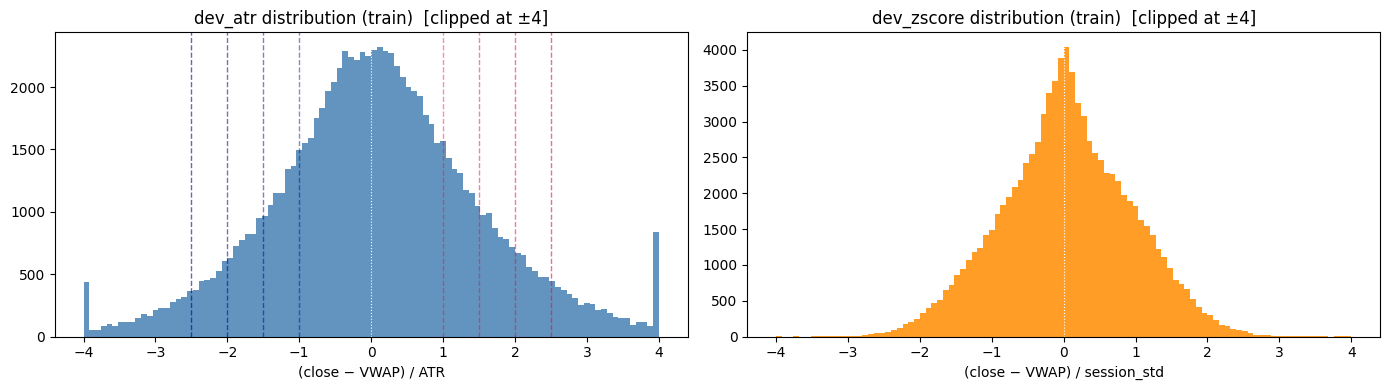

Saved: 06a_dev_distributions.png
Cell 4 OK


In [4]:
# ── Train filter + distribution characterization ──────────────────────────────
# HOLDOUT IS NEVER TOUCHED. All analysis below uses train only.

df['split'] = 'holdout'
df.loc[df['open_time'] < SPLIT_DATE, 'split'] = 'train'

train = df[df['split'] == 'train'].copy()
n_train_candles = len(train)
n_train_days    = train['date'].nunique()

print(f'TRAIN: {n_train_candles:,} session candles | {n_train_days:,} trading days')
print(f'       {train["open_time"].iloc[0].date()} → {train["open_time"].iloc[-1].date()}')
print()
print('dev_atr distribution (train):')
print(train['dev_atr'].describe().round(4).to_string())
print()
print('Event frequency by threshold (per day avg):')
print(f'  {"Threshold":>10}  {"SHORT":>6}  {"LONG":>6}  {"Total":>7}  {"Events/day":>11}')
for T in THRESHOLDS:
    n_s = (train['dev_atr'] >  T).sum()
    n_l = (train['dev_atr'] < -T).sum()
    n_t = n_s + n_l
    print(f'  {T:>10.1f}  {n_s:>6}  {n_l:>6}  {n_t:>7}  {n_t/n_train_days:>11.2f}')

# Both distribution lenses
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(train['dev_atr'].clip(-4, 4), bins=100, color='steelblue', edgecolor='none', alpha=0.85)
for T in THRESHOLDS:
    axes[0].axvline( T, color='crimson', alpha=0.35 + T*0.1, lw=1, ls='--')
    axes[0].axvline(-T, color='navy',    alpha=0.35 + T*0.1, lw=1, ls='--')
axes[0].set_title('dev_atr distribution (train)  [clipped at ±4]')
axes[0].set_xlabel('(close − VWAP) / ATR')
axes[0].axvline(0, color='white', lw=0.8, ls=':')

axes[1].hist(train['dev_zscore'].clip(-4, 4), bins=100, color='darkorange', edgecolor='none', alpha=0.85)
axes[1].axvline(0, color='white', lw=0.8, ls=':')
axes[1].set_title('dev_zscore distribution (train)  [clipped at ±4]')
axes[1].set_xlabel('(close − VWAP) / session_std')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '06a_dev_distributions.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: 06a_dev_distributions.png')
print('Cell 4 OK')

In [5]:
# ── Forward close columns (vectorized, within-session only) ───────────────────
# Shift within day groups → cross-session leakage is impossible (NaN at boundary)

print(f'Computing {MAX_HORIZON} forward close columns...')
for h in range(1, MAX_HORIZON + 1):
    df[f'fwd_c{h}'] = df.groupby('date')['close'].shift(-h)

# High/Low columns (for reversion hit detection)
for h in range(1, MAX_HORIZON + 1):
    df[f'fwd_h{h}'] = df.groupby('date')['high'].shift(-h)
    df[f'fwd_l{h}'] = df.groupby('date')['low'].shift(-h)

# For each FWD_HORIZONS N: compute forward min/max of candle bodies
for N in FWD_HORIZONS:
    fwd_close_cols = [f'fwd_c{h}' for h in range(1, N + 1)]
    fwd_low_cols   = [f'fwd_l{h}' for h in range(1, N + 1)]
    fwd_high_cols  = [f'fwd_h{h}' for h in range(1, N + 1)]
    df[f'fwd_min_close_{N}c'] = df[fwd_close_cols].min(axis=1)
    df[f'fwd_max_close_{N}c'] = df[fwd_close_cols].max(axis=1)
    df[f'fwd_min_low_{N}c']   = df[fwd_low_cols].min(axis=1)
    df[f'fwd_max_high_{N}c']  = df[fwd_high_cols].max(axis=1)

# Direction-signed toward-VWAP returns per horizon (positive = moved toward VWAP)
# For above-VWAP (dev_atr > 0): toward = price drop → (entry_close - fwd_close) / entry_close
# For below-VWAP (dev_atr < 0): toward = price rise → (fwd_close - entry_close) / entry_close
for h in range(1, MAX_HORIZON + 1):
    df[f'toward_{h}c'] = np.where(
        df['dev_atr'] >= 0,
        (df['close'] - df[f'fwd_c{h}']) / df['close'],
        (df[f'fwd_c{h}'] - df['close']) / df['close']
    )

toward_cols_all = [f'toward_{h}c' for h in range(1, MAX_HORIZON + 1)]

# MFE and MAE over MAX_HORIZON (vectorized)
toward_df       = df[toward_cols_all]
df['mfe_20c']   = toward_df.max(axis=1)           # best toward-VWAP excursion
df['mae_20c']   = (-toward_df).max(axis=1)        # worst adverse excursion

# Re-extract train (now with new columns)
train = df[df['split'] == 'train'].copy()

print(f'Done. Columns added: fwd_cN, fwd_hN, fwd_lN, fwd_min/max, toward_Nc, mfe_20c, mae_20c')
print(f'Train shape: {train.shape}')
print('Cell 5 OK')

Computing 20 forward close columns...
Done. Columns added: fwd_cN, fwd_hN, fwd_lN, fwd_min/max, toward_Nc, mfe_20c, mae_20c
Train shape: (90714, 130)
Cell 5 OK


In [6]:
# ── Forward return distributions by threshold ──────────────────────────────────
# Core question: given |dev_atr| > T, what happens next?
# Using toward_Nc (positive = moved toward VWAP)

print('Forward return distributions — toward VWAP (train only)')
print('Positive = moved toward VWAP  |  Unit = % of entry price')
print()

fwd_results = []
for T in THRESHOLDS:
    for direction, mask in [('SHORT', train['dev_atr'] >  T),
                              ('LONG',  train['dev_atr'] < -T)]:
        events = train[mask].copy()
        row = {'threshold': T, 'direction': direction, 'n_events': len(events)}
        for h in FWD_HORIZONS:
            col = f'toward_{h}c'
            val = events[col].dropna()
            if len(val) == 0: continue
            row[f'mean_{h}c']  = round(val.mean()  * 100, 4)
            row[f'p25_{h}c']   = round(val.quantile(0.25) * 100, 4)
            row[f'p50_{h}c']   = round(val.quantile(0.50) * 100, 4)
            row[f'p75_{h}c']   = round(val.quantile(0.75) * 100, 4)
            row[f'ppos_{h}c']  = round((val > 0).mean() * 100, 1)
            # t-test: is mean significantly different from zero?
            t_stat, p_val = stats.ttest_1samp(val.dropna(), 0)
            row[f'pval_{h}c']  = round(p_val, 4)
        fwd_results.append(row)

frd = pd.DataFrame(fwd_results)

print('P50 (median) forward return toward VWAP [%]:')
p50_cols = ['threshold', 'direction', 'n_events'] + [f'p50_{h}c' for h in FWD_HORIZONS]
print(frd[p50_cols].to_string(index=False))
print()
print('P(positive return toward VWAP) [%]:')
ppos_cols = ['threshold', 'direction', 'n_events'] + [f'ppos_{h}c' for h in FWD_HORIZONS]
print(frd[ppos_cols].to_string(index=False))
print()
print('t-test p-values (H0: mean = 0):')
pval_cols = ['threshold', 'direction', 'n_events'] + [f'pval_{h}c' for h in FWD_HORIZONS]
print(frd[pval_cols].to_string(index=False))

frd.to_csv(OUTPUT_DIR / '06a_forward_returns.csv', index=False)
print('\nSaved: 06a_forward_returns.csv')
print('Cell 6 OK')

Forward return distributions — toward VWAP (train only)
Positive = moved toward VWAP  |  Unit = % of entry price

P50 (median) forward return toward VWAP [%]:
 threshold direction  n_events  p50_1c  p50_3c  p50_5c  p50_10c  p50_20c
       1.0     SHORT     21668  0.0106  0.0199  0.0234   0.0250   0.0393
       1.0      LONG     18928  0.0155  0.0314  0.0395   0.0494   0.0563
       1.5     SHORT     13719  0.0132  0.0243  0.0311   0.0308   0.0335
       1.5      LONG     11407  0.0206  0.0390  0.0480   0.0565   0.0766
       2.0     SHORT      8338  0.0169  0.0312  0.0376   0.0317   0.0392
       2.0      LONG      6452  0.0286  0.0470  0.0549   0.0566   0.0954
       2.5     SHORT      4853  0.0201  0.0344  0.0398   0.0284   0.0308
       2.5      LONG      3495  0.0323  0.0526  0.0662   0.0541   0.1124

P(positive return toward VWAP) [%]:
 threshold direction  n_events  ppos_1c  ppos_3c  ppos_5c  ppos_10c  ppos_20c
       1.0     SHORT     21668     53.4     53.8     53.6      53.1  

In [7]:
# ── Path shape analysis: MFE vs MAE ───────────────────────────────────────────
# Key question: does the FAVORABLE move dominate the ADVERSE move?
# If MFE_p50 > MAE_p50 consistently → path supports extractable drift
# If MAE consistently beats MFE → position liquidated before reversion

print('Path shape: MFE toward VWAP vs MAE away from VWAP (train, MAX_HORIZON=20 candles)')
print()

path_rows = []
for T in THRESHOLDS:
    ev = train[train['abs_dev_atr'] > T].dropna(subset=['mfe_20c', 'mae_20c']).copy()
    if len(ev) < 20: continue

    row = {
        'threshold': T,
        'n':         len(ev),
        'mfe_p25':   round(ev['mfe_20c'].quantile(0.25) * 100, 4),
        'mfe_p50':   round(ev['mfe_20c'].quantile(0.50) * 100, 4),
        'mfe_p75':   round(ev['mfe_20c'].quantile(0.75) * 100, 4),
        'mae_p25':   round(ev['mae_20c'].quantile(0.25) * 100, 4),
        'mae_p50':   round(ev['mae_20c'].quantile(0.50) * 100, 4),
        'mae_p75':   round(ev['mae_20c'].quantile(0.75) * 100, 4),
        'pct_mfe_gt_mae': round((ev['mfe_20c'] > ev['mae_20c']).mean() * 100, 1),
        'mfe_mae_ratio':  round((ev['mfe_20c'] / ev['mae_20c'].clip(lower=1e-6)).median(), 3),
    }
    path_rows.append(row)

pdf = pd.DataFrame(path_rows)
print(pdf.to_string(index=False))
print()
print('Interpretation guide:')
print('  mfe_p50 > mae_p50  → median trade sees MORE favorable than adverse path (good)')
print('  pct_mfe_gt_mae > 50% → more than half events: favorable exceeds adverse')
print('  mfe_mae_ratio > 1.0  → favorable exceeds adverse (median ratio)')

# Build horizon-by-horizon MFE using toward_cols
print('\nMFE toward VWAP at each horizon (P50 across all |dev_atr|>T events):')
mfe_table_rows = []
for T in THRESHOLDS:
    ev = train[train['abs_dev_atr'] > T]
    row = {'threshold': T, 'n': len(ev)}
    for h in FWD_HORIZONS:
        col = f'toward_{h}c'
        if col in ev.columns:
            row[f'mfe_capped_{h}c'] = round(ev[col].clip(lower=0).quantile(0.50)*100, 4)  # MFE proxy (toward>=0)
    mfe_table_rows.append(row)

print(pd.DataFrame(mfe_table_rows).to_string(index=False))
print('Cell 7 OK')

Path shape: MFE toward VWAP vs MAE away from VWAP (train, MAX_HORIZON=20 candles)

 threshold     n  mfe_p25  mfe_p50  mfe_p75  mae_p25  mae_p50  mae_p75  pct_mfe_gt_mae  mfe_mae_ratio
       1.0 39383   0.0707   0.2546   0.5769   0.0377   0.2312   0.6113            51.4          1.099
       1.5 24179   0.0622   0.2500   0.5674   0.0271   0.2222   0.5984            51.6          1.114
       2.0 14119   0.0543   0.2408   0.5530   0.0150   0.2120   0.5947            51.8          1.131
       2.5  7882   0.0459   0.2297   0.5388   0.0048   0.2009   0.5951            52.2          1.175

Interpretation guide:
  mfe_p50 > mae_p50  → median trade sees MORE favorable than adverse path (good)
  pct_mfe_gt_mae > 50% → more than half events: favorable exceeds adverse
  mfe_mae_ratio > 1.0  → favorable exceeds adverse (median ratio)

MFE toward VWAP at each horizon (P50 across all |dev_atr|>T events):
 threshold     n  mfe_capped_1c  mfe_capped_3c  mfe_capped_5c  mfe_capped_10c  mfe_capped_20c

In [8]:
# ── Reversion probability analysis ────────────────────────────────────────────
# P(price achieves X% reversion from entry toward VWAP within N candles)
# Using high/low of forward candles for intracandle detection.
# Full reversion = price crosses VWAP (using close as proxy).

print('Reversion probabilities (train only)')
print()

rev_rows = []
for T in THRESHOLDS:
    ev = train[train['abs_dev_atr'] > T].copy()
    if len(ev) < 10: continue

    # Original distance from VWAP (absolute, in price terms)
    ev['orig_dist'] = (ev['close'] - ev['vwap']).abs()  # same as |dev_raw|

    # Target prices for partial reversion
    # For above-VWAP (dev_atr > 0): reversion means price DROPS
    #   25% reversion target: entry_close - 0.25 * orig_dist
    # For below-VWAP (dev_atr < 0): reversion means price RISES
    #   25% reversion target: entry_close + 0.25 * orig_dist
    for frac, label in [(0.25, 'rev25'), (0.50, 'rev50'), (0.75, 'rev75'), (1.00, 'full_cross')]:
        ev[f'target_{label}'] = np.where(
            ev['dev_atr'] > 0,
            ev['close'] - frac * ev['orig_dist'],   # target below for SHORT
            ev['close'] + frac * ev['orig_dist']    # target above for LONG
        )

    row = {'threshold': T, 'n': len(ev)}

    for N in FWD_HORIZONS:
        fwd_min_col  = f'fwd_min_low_{N}c'     # min low across N candles
        fwd_max_col  = f'fwd_max_high_{N}c'    # max high across N candles

        if fwd_min_col not in ev.columns: continue

        for frac, label in [(0.25, 'rev25'), (0.50, 'rev50'), (0.75, 'rev75'), (1.00, 'full_cross')]:
            # SHORT events: did fwd_min_low reach target (below entry)?
            # LONG events:  did fwd_max_high reach target (above entry)?
            hit_above = (ev['dev_atr'] > 0)  & (ev[fwd_min_col] <= ev[f'target_{label}'])
            hit_below = (ev['dev_atr'] < 0)  & (ev[fwd_max_col] >= ev[f'target_{label}'])
            p_hit = (hit_above | hit_below).mean()
            row[f'p_{label}_{N}c'] = round(p_hit * 100, 1)

    rev_rows.append(row)

rev_df = pd.DataFrame(rev_rows)

print('P(price achieves reversion fraction within N candles) [%]:')
print()
for T in THRESHOLDS:
    sub = rev_df[rev_df['threshold'] == T]
    if len(sub) == 0: continue
    row = sub.iloc[0]
    print(f'|dev_atr| > {T:.1f}  (n={int(row["n"]):,}):')
    header = f'  {"Reversion":>12}' + ''.join(f'  {N:>5}c' for N in FWD_HORIZONS)
    print(header)
    for label in ['rev25', 'rev50', 'rev75', 'full_cross']:
        line = f'  {label:>12}' + ''.join(
            f'  {row.get(f"p_{label}_{N}c", float("nan")):>5.1f}%' for N in FWD_HORIZONS
        )
        print(line)
    print()

rev_df.to_csv(OUTPUT_DIR / '06a_reversion_probs.csv', index=False)
print('Saved: 06a_reversion_probs.csv')
print('Cell 8 OK')

Reversion probabilities (train only)

P(price achieves reversion fraction within N candles) [%]:

|dev_atr| > 1.0  (n=40,596):
     Reversion      1c      3c      5c     10c     20c
         rev25   48.7%   66.8%   72.5%   77.3%   79.2%
         rev50   20.1%   40.8%   50.0%   59.0%   63.6%
         rev75    8.2%   24.0%   33.6%   45.1%   51.9%
    full_cross    3.9%   14.4%   22.6%   34.0%   42.5%

|dev_atr| > 1.5  (n=25,126):
     Reversion      1c      3c      5c     10c     20c
         rev25   41.6%   61.2%   67.5%   72.5%   74.3%
         rev50   12.8%   32.0%   41.4%   50.6%   55.3%
         rev75    4.2%   15.8%   24.4%   35.3%   42.1%
    full_cross    1.9%    8.5%   14.7%   24.4%   32.5%

|dev_atr| > 2.0  (n=14,790):
     Reversion      1c      3c      5c     10c     20c
         rev25   36.0%   56.2%   62.6%   67.6%   69.3%
         rev50    8.8%   25.4%   34.1%   42.8%   47.2%
         rev75    2.6%   11.0%   17.8%   27.1%   33.4%
    full_cross    1.2%    5.5%   10.1%   17

In [9]:
# ── Continuation vs reversion ──────────────────────────────────────────────────
# Central hypothesis falsification:
#   H0: P(revert toward VWAP | |dev_atr|>T) is not meaningfully > 50%
#   H1: extension events show systematic reversion tendency

print('Continuation vs reversion probabilities — train only')
print('Using toward_1c: single-candle direction test (most conservative)')
print()

for T in THRESHOLDS:
    ev = train[train['abs_dev_atr'] > T].dropna(subset=['toward_1c']).copy()
    if len(ev) < 20: continue

    p_toward = (ev['toward_1c'] > 0).mean()
    p_away   = (ev['toward_1c'] < 0).mean()
    mean_ret = ev['toward_1c'].mean()

    # Binomial test: is p_toward significantly > 50%?
    binom_p = stats.binomtest(int(p_toward * len(ev)), n=len(ev), p=0.5, alternative='greater').pvalue

    print(f'|dev_atr| > {T:.1f}  (n={len(ev):,}):')
    print(f'  P(toward VWAP next candle)  = {p_toward*100:.1f}%')
    print(f'  P(away   from VWAP)         = {p_away*100:.1f}%')
    print(f'  Mean toward return          = {mean_ret*100:+.4f}%')
    print(f'  Binomial p-val (>50% test)  = {binom_p:.4f}  {"*** (p<0.05)" if binom_p < 0.05 else "ns"}')
    print()

# Multi-candle: cumulative toward-VWAP over horizons
print('Mean toward-VWAP return at each horizon (train):')
print(f'  {"Threshold":>10}  {"n":>6}' + ''.join(f'  {h:>6}c' for h in FWD_HORIZONS))
for T in THRESHOLDS:
    ev = train[train['abs_dev_atr'] > T]
    means = []
    for h in FWD_HORIZONS:
        col = f'toward_{h}c'
        means.append(ev[col].mean() * 100 if col in ev.columns else float('nan'))
    line = f'  {T:>10.1f}  {len(ev):>6}' + ''.join(f'  {m:>+6.4f}' for m in means)
    print(line)

print('Cell 9 OK')

Continuation vs reversion probabilities — train only
Using toward_1c: single-candle direction test (most conservative)

|dev_atr| > 1.0  (n=39,383):
  P(toward VWAP next candle)  = 53.9%
  P(away   from VWAP)         = 46.0%
  Mean toward return          = +0.0008%
  Binomial p-val (>50% test)  = 0.0000  *** (p<0.05)

|dev_atr| > 1.5  (n=24,179):
  P(toward VWAP next candle)  = 54.6%
  P(away   from VWAP)         = 45.3%
  Mean toward return          = +0.0029%
  Binomial p-val (>50% test)  = 0.0000  *** (p<0.05)

|dev_atr| > 2.0  (n=14,119):
  P(toward VWAP next candle)  = 55.3%
  P(away   from VWAP)         = 44.5%
  Mean toward return          = +0.0041%
  Binomial p-val (>50% test)  = 0.0000  *** (p<0.05)

|dev_atr| > 2.5  (n=7,882):
  P(toward VWAP next candle)  = 55.5%
  P(away   from VWAP)         = 44.4%
  Mean toward return          = +0.0066%
  Binomial p-val (>50% test)  = 0.0000  *** (p<0.05)

Mean toward-VWAP return at each horizon (train):
   Threshold       n       1c   

In [10]:
# ── Summary: empirically-grounded TP/SL candidates for Exp 06b ─────────────────
# These are OBSERVATIONS, not optimization targets.
# 06b will test if any of these yield E_net > 0 on holdout.

SEP = '='*65
print(SEP)
print('  EXP 06a — VWAP EXCURSION STUDY SUMMARY')
print('  (train-only observations for 06b design)')
print(SEP)

summary_rows = []
for T in THRESHOLDS:
    ev = train[train['abs_dev_atr'] > T].dropna(subset=['mfe_20c', 'mae_20c', 'toward_1c'])
    rev_row = rev_df[rev_df['threshold'] == T]
    if len(ev) < 10: continue

    # From forward return distributions
    toward_5c = ev[f'toward_5c'].dropna() if 'toward_5c' in ev else pd.Series(dtype=float)
    toward_10c = ev['toward_10c'].dropna() if 'toward_10c' in ev else pd.Series(dtype=float)

    mfe_p50 = ev['mfe_20c'].quantile(0.50) * 100
    mae_p50 = ev['mae_20c'].quantile(0.50) * 100
    mfe_p25 = ev['mfe_20c'].quantile(0.25) * 100

    # TP candidate: P50 of MFE (50% of events achieve this favorable move)
    # SL candidate: P50 of MAE (median adverse excursion before reversal)
    tp_cand = mfe_p50
    sl_cand = mae_p50
    be_wr   = (sl_cand + COSTS_TOTAL * 100) / (sl_cand + tp_cand) if sl_cand + tp_cand > 0 else 1.0

    p_toward_1c = (ev['toward_1c'] > 0).mean() * 100
    p_rev50_10c = rev_row['p_rev50_10c'].values[0] if len(rev_row) and 'p_rev50_10c' in rev_row else float('nan')

    row = {
        'threshold': T,
        'events/day': round(len(ev) / n_train_days, 2),
        'P(toward 1c)%': round(p_toward_1c, 1),
        'P(>=50% rev, 10c)%': round(p_rev50_10c, 1),
        'MFE_p50%': round(mfe_p50, 4),
        'MAE_p50%': round(mae_p50, 4),
        'P(MFE>MAE)%': round((ev['mfe_20c'] > ev['mae_20c']).mean() * 100, 1),
        'TP_cand%': round(tp_cand, 4),
        'SL_cand%': round(sl_cand, 4),
        'BE_WR%': round(be_wr * 100, 1),
    }
    summary_rows.append(row)

sum_df = pd.DataFrame(summary_rows)
print(sum_df.to_string(index=False))
print()
print('Columns guide:')
print('  P(toward 1c)%   — probability next candle moves toward VWAP')
print('  P(>=50% rev 10c)— probability of >=50% reversion within 10 candles')
print('  MFE/MAE_p50     — median best/worst excursion over 20 candles')
print('  P(MFE>MAE)      — fraction where favorable beat adverse')
print('  TP/SL_cand      — empirical candidates based on P50 MFE/MAE')
print('  BE_WR           — break-even WR at these TP/SL + taker costs')
print()
print('These inform 06b design — they are NOT parameters to optimize.')
print('If BE_WR >> observed P(toward), the family is likely unviable at any scale.')

sum_df.to_csv(OUTPUT_DIR / '06a_summary.csv', index=False)
print(SEP)
print('Saved: 06a_summary.csv')
print('Cell 10 OK')

  EXP 06a — VWAP EXCURSION STUDY SUMMARY
  (train-only observations for 06b design)
 threshold  events/day  P(toward 1c)%  P(>=50% rev, 10c)%  MFE_p50%  MAE_p50%  P(MFE>MAE)%  TP_cand%  SL_cand%  BE_WR%
       1.0       20.83           53.9                59.0    0.2546    0.2312         51.4    0.2546    0.2312    64.1
       1.5       12.79           54.6                50.6    0.2500    0.2222         51.6    0.2500    0.2222    64.0
       2.0        7.47           55.3                42.8    0.2408    0.2120         51.8    0.2408    0.2120    64.5
       2.5        4.17           55.5                35.8    0.2297    0.2009         52.2    0.2297    0.2009    65.2

Columns guide:
  P(toward 1c)%   — probability next candle moves toward VWAP
  P(>=50% rev 10c)— probability of >=50% reversion within 10 candles
  MFE/MAE_p50     — median best/worst excursion over 20 candles
  P(MFE>MAE)      — fraction where favorable beat adverse
  TP/SL_cand      — empirical candidates based on P5

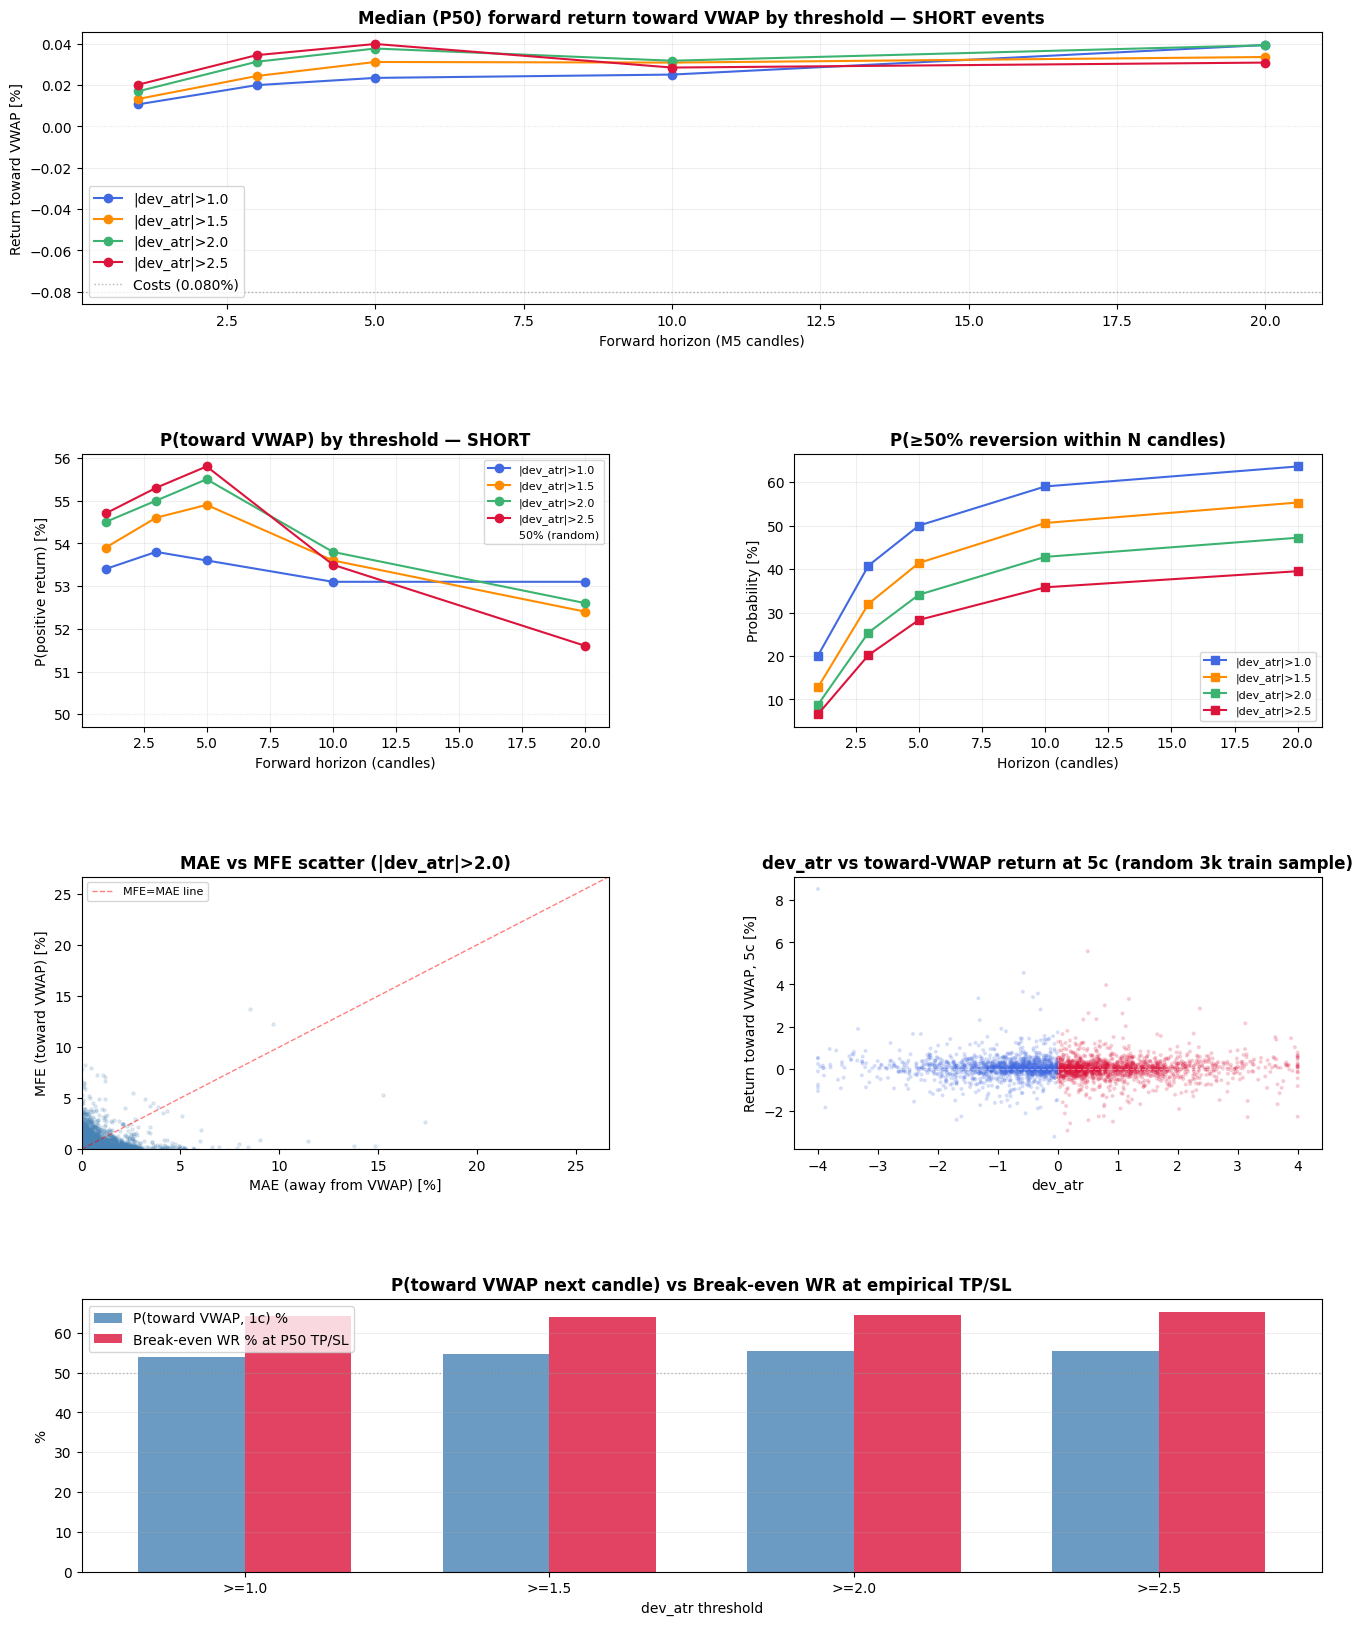

Saved: 06a_visualizations.png
Cell 11 OK — 06a complete


In [11]:
# ── Visualizations ─────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(16, 20))
gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.55, wspace=0.35)

# 1. Forward return distributions (P50) across thresholds and horizons
ax1 = fig.add_subplot(gs[0, :])
colors = ['royalblue', 'darkorange', 'mediumseagreen', 'crimson']
for i, T in enumerate(THRESHOLDS):
    sub = frd[(frd['threshold'] == T) & (frd['direction'] == 'SHORT')]
    if len(sub) == 0: continue
    p50_vals = [sub[f'p50_{h}c'].values[0] for h in FWD_HORIZONS]
    ax1.plot(FWD_HORIZONS, p50_vals, marker='o', color=colors[i], label=f'|dev_atr|>{T}')
ax1.axhline(0, color='white', lw=0.8, ls='--', alpha=0.5)
ax1.axhline(-COSTS_TOTAL * 100, color='gray', lw=1, ls=':', alpha=0.6, label=f'Costs ({COSTS_TOTAL*100:.3f}%)')
ax1.set_title('Median (P50) forward return toward VWAP by threshold — SHORT events', fontweight='bold')
ax1.set_xlabel('Forward horizon (M5 candles)'); ax1.set_ylabel('Return toward VWAP [%]')
ax1.legend(); ax1.grid(alpha=0.2)

# 2. P(toward VWAP) by horizon and threshold
ax2 = fig.add_subplot(gs[1, 0])
for i, T in enumerate(THRESHOLDS):
    sub = frd[(frd['threshold'] == T) & (frd['direction'] == 'SHORT')]
    if len(sub) == 0: continue
    ppos_vals = [sub[f'ppos_{h}c'].values[0] for h in FWD_HORIZONS]
    ax2.plot(FWD_HORIZONS, ppos_vals, marker='o', color=colors[i], label=f'|dev_atr|>{T}')
ax2.axhline(50, color='white', lw=0.8, ls='--', alpha=0.5, label='50% (random)')
ax2.set_title('P(toward VWAP) by threshold — SHORT', fontweight='bold')
ax2.set_xlabel('Forward horizon (candles)'); ax2.set_ylabel('P(positive return) [%]')
ax2.legend(fontsize=8); ax2.grid(alpha=0.2)

# 3. Reversion hit probabilities (rev50, within 10 candles)
ax3 = fig.add_subplot(gs[1, 1])
if len(rev_df) > 0:
    horizons_plot = [h for h in FWD_HORIZONS if f'p_rev50_{h}c' in rev_df.columns]
    for i, T in enumerate(THRESHOLDS):
        sub = rev_df[rev_df['threshold'] == T]
        if len(sub) == 0: continue
        row = sub.iloc[0]
        vals = [row.get(f'p_rev50_{h}c', float('nan')) for h in horizons_plot]
        ax3.plot(horizons_plot, vals, marker='s', color=colors[i], label=f'|dev_atr|>{T}')
ax3.set_title('P(≥50% reversion within N candles)', fontweight='bold')
ax3.set_xlabel('Horizon (candles)'); ax3.set_ylabel('Probability [%]')
ax3.legend(fontsize=8); ax3.grid(alpha=0.2)

# 4. MAE vs MFE scatter (sample, T=2.0)
ax4 = fig.add_subplot(gs[2, 0])
T_plot = 2.0
ev_plot = train[train['abs_dev_atr'] > T_plot].dropna(subset=['mfe_20c', 'mae_20c'])
if len(ev_plot) > 0:
    ax4.scatter(ev_plot['mae_20c'] * 100, ev_plot['mfe_20c'] * 100,
                alpha=0.15, s=5, color='steelblue')
    lim = max(ev_plot[['mfe_20c', 'mae_20c']].max().max() * 100 * 1.1, 0.5)
    ax4.plot([0, lim], [0, lim], 'r--', lw=1, alpha=0.5, label='MFE=MAE line')
    ax4.set_xlim(0, lim); ax4.set_ylim(0, lim)
    ax4.set_xlabel('MAE (away from VWAP) [%]'); ax4.set_ylabel('MFE (toward VWAP) [%]')
ax4.set_title(f'MAE vs MFE scatter (|dev_atr|>{T_plot})', fontweight='bold')
ax4.legend(fontsize=8)

# 5. dev_atr vs forward return (scatter, 5c horizon)
ax5 = fig.add_subplot(gs[2, 1])
sample = train.dropna(subset=['toward_5c']).sample(min(3000, len(train)), random_state=42)
colors_scatter = np.where(sample['dev_atr'] > 0, 'crimson', 'royalblue')
ax5.scatter(sample['dev_atr'].clip(-4, 4), sample['toward_5c'] * 100,
            alpha=0.15, s=4, c=colors_scatter)
ax5.axhline(0, color='white', lw=0.8, ls='--', alpha=0.4)
ax5.axvline(0, color='white', lw=0.8, ls='--', alpha=0.4)
ax5.set_title('dev_atr vs toward-VWAP return at 5c (random 3k train sample)', fontweight='bold')
ax5.set_xlabel('dev_atr'); ax5.set_ylabel('Return toward VWAP, 5c [%]')

# 6. Break-even WR vs threshold summary
ax6 = fig.add_subplot(gs[3, :])
if len(sum_df) > 0:
    x = range(len(sum_df))
    width = 0.35
    ax6.bar([xi - width/2 for xi in x], sum_df['P(toward 1c)%'], width,
            label='P(toward VWAP, 1c) %', color='steelblue', alpha=0.8)
    ax6.bar([xi + width/2 for xi in x], sum_df['BE_WR%'], width,
            label='Break-even WR % at P50 TP/SL', color='crimson', alpha=0.8)
    ax6.set_xticks(list(x))
    ax6.set_xticklabels([f'>={T}' for T in sum_df['threshold']])
    ax6.set_xlabel('dev_atr threshold'); ax6.set_ylabel('%')
    ax6.set_title('P(toward VWAP next candle) vs Break-even WR at empirical TP/SL', fontweight='bold')
    ax6.legend(); ax6.grid(axis='y', alpha=0.2)
    ax6.axhline(50, color='gray', ls=':', lw=1, alpha=0.5)

plt.savefig(OUTPUT_DIR / '06a_visualizations.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: 06a_visualizations.png')
print('Cell 11 OK — 06a complete')